In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon, FancyArrowPatch
from matplotlib.animation import FuncAnimation
import inspect, ast

In [2]:
def draw_box(ax, xy, w, h, text, fc, ec="black"):
    x, y = xy
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.02",
                         facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10)
    return box

def draw_diamond(ax, xy, w, h, text, fc, ec="black"):
    x, y = xy
    pts = [(x, y + h/2), (x + w/2, y), (x, y - h/2), (x - w/2, y)]
    poly = Polygon(pts, closed=True, facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(poly)
    ax.text(x, y, text, ha='center', va='center', fontsize=10)
    return poly

def draw_arrow(ax, p1, p2):
    arr = FancyArrowPatch(p1, p2, arrowstyle="->", linewidth=1.5)
    ax.add_patch(arr)
    return arr

In [3]:
THEMES = {
    "dark":  {"bg":"black", "node":"skyblue", "decision":"gold", "text":"white"},
    "light": {"bg":"white", "node":"lightblue", "decision":"orange", "text":"black"},
    "neon":  {"bg":"black", "node":"cyan", "decision":"magenta", "text":"white"}
}

theme = THEMES["dark"]

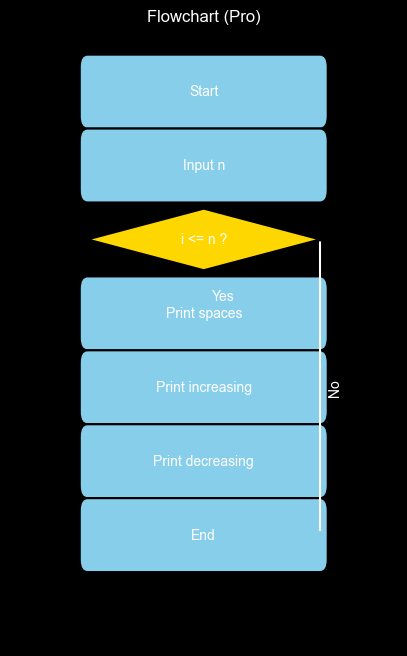

In [4]:
fig, ax = plt.subplots(figsize=(5, 8))
fig.patch.set_facecolor(theme["bg"])
ax.set_facecolor(theme["bg"])

# Node positions (top to bottom)
ys = [0.9, 0.78, 0.66, 0.54, 0.42, 0.30, 0.18]
x = 0.5

nodes = []
labels = [
    ("Start", "box"),
    ("Input n", "box"),
    ("i <= n ?", "diamond"),  # decision
    ("Print spaces", "box"),
    ("Print increasing", "box"),
    ("Print decreasing", "box"),
    ("End", "box")
]

# Draw nodes
for (text, kind), y in zip(labels, ys):
    if kind == "box":
        nodes.append(draw_box(ax, (x, y), 0.6, 0.08, text, fc=theme["node"]))
    else:
        nodes.append(draw_diamond(ax, (x, y), 0.6, 0.10, text, fc=theme["decision"]))

# Arrows (linear + decision branches)
arrows = []
for i in range(len(ys) - 1):
    arrows.append(draw_arrow(ax, (x, ys[i] - 0.06), (x, ys[i+1] + 0.06)))

# Decision side branches (Yes/No)
# Yes → down (already drawn)
# No → jump to End
arrows.append(draw_arrow(ax, (x + 0.3, ys[2]), (x + 0.3, ys[-1])))
ax.text(x + 0.32, (ys[2] + ys[-1]) / 2, "No", color=theme["text"], rotation=90, va='center')
ax.text(x + 0.02, ys[2] - 0.1, "Yes", color=theme["text"])

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title("Flowchart (Pro)", color=theme["text"])
plt.show()

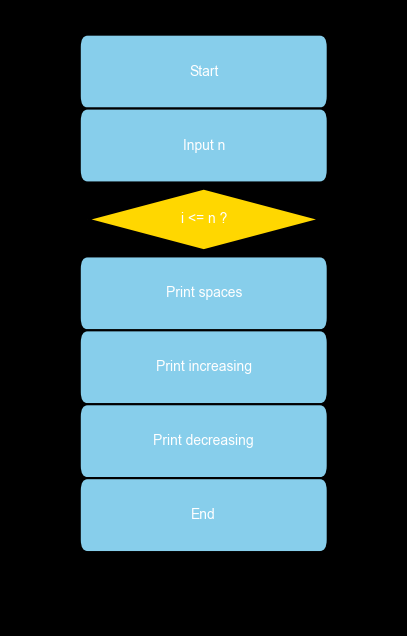

In [5]:
fig, ax = plt.subplots(figsize=(5, 8))
fig.patch.set_facecolor(theme["bg"])
ax.set_facecolor(theme["bg"])

# Rebuild nodes for animation
ys = [0.9, 0.78, 0.66, 0.54, 0.42, 0.30, 0.18]
x = 0.5
patches = []
for (text, kind), y in zip(labels, ys):
    if kind == "box":
        p = draw_box(ax, (x, y), 0.6, 0.08, text, fc=theme["node"])
    else:
        p = draw_diamond(ax, (x, y), 0.6, 0.10, text, fc=theme["decision"])
    patches.append(p)

for i in range(len(ys) - 1):
    draw_arrow(ax, (x, ys[i] - 0.06), (x, ys[i+1] + 0.06))

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

def animate(i):
    for j, p in enumerate(patches):
        p.set_linewidth(1.5)
        p.set_edgecolor("black")
    k = i % len(patches)
    patches[k].set_linewidth(3)
    patches[k].set_edgecolor("red")
    return patches

ani = FuncAnimation(fig, animate, frames=range(20), interval=400, blit=False)
plt.show()

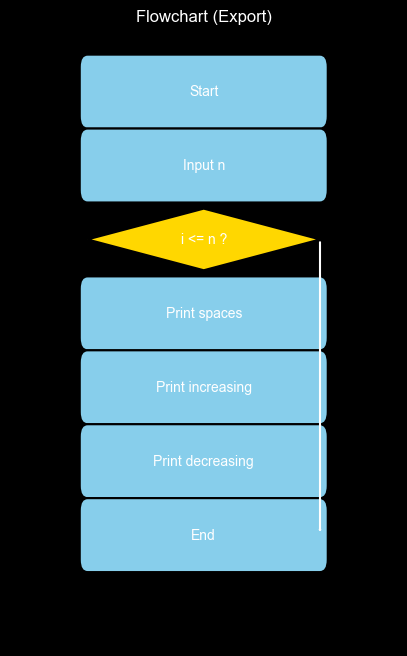

In [6]:
# Reuse the static figure from Cell 4 by rebuilding quickly
fig, ax = plt.subplots(figsize=(5, 8))
fig.patch.set_facecolor(theme["bg"])
ax.set_facecolor(theme["bg"])

ys = [0.9, 0.78, 0.66, 0.54, 0.42, 0.30, 0.18]
x = 0.5

for (text, kind), y in zip(labels, ys):
    if kind == "box":
        draw_box(ax, (x, y), 0.6, 0.08, text, fc=theme["node"])
    else:
        draw_diamond(ax, (x, y), 0.6, 0.10, text, fc=theme["decision"])

for i in range(len(ys) - 1):
    draw_arrow(ax, (x, ys[i] - 0.06), (x, ys[i+1] + 0.06))

draw_arrow(ax, (x + 0.3, ys[2]), (x + 0.3, ys[-1]))

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
plt.title("Flowchart (Export)", color=theme["text"])

plt.savefig("flowchart.png", dpi=300, bbox_inches="tight")
plt.savefig("flowchart.pdf", bbox_inches="tight")
plt.show()

In [7]:
def example_func(n):
    i = 1
    while i <= n:
        print("spaces")
        print("inc")
        print("dec")
        i += 1

def extract_steps(func):
    src = inspect.getsource(func)
    tree = ast.parse(src)
    steps = ["Start"]
    for node in ast.walk(tree):
        if isinstance(node, ast.While):
            steps.append("While condition")
        if isinstance(node, ast.For):
            steps.append("For loop")
        if isinstance(node, ast.Assign):
            steps.append("Assignment")
        if isinstance(node, ast.Expr):
            steps.append("Action")
    steps.append("End")
    # Deduplicate while preserving order
    seen = set()
    uniq = []
    for s in steps:
        if s not in seen:
            uniq.append(s); seen.add(s)
    return uniq

auto_steps = extract_steps(example_func)
auto_steps

['Start', 'Assignment', 'While condition', 'Action', 'End']